# **XGBoost Model**

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import preprocessing
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split,\
StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.metrics import confusion_matrix, plot_roc_curve,roc_auc_score,f1_score
from sklearn.feature_selection import RFE
from yellowbrick.classifier import confusion_matrix, classification_report, ROCAUC
from yellowbrick.model_selection import CVScores
plt.style.use('ggplot')
import warnings
warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', 100)

Intel(R) Extension for Scikit-learn* enabled (https://github.com/intel/scikit-learn-intelex)


In [ ]:
def show_values(axs, orient="v", space=.01):
		_single(axs)

def mba_process(df):

	# Creating categories

	df["Gender"] = df["Gender"].apply(lambda x: "Male" if x == 1 else "Female")

	df["ChronicCond_Alzheimer"] = df["ChronicCond_Alzheimer"]\
					.apply(lambda x: "no_alzheimer" if x == 1 else "has_alzheimer")

	df["ChronicCond_Heartfailure"] = df["ChronicCond_Heartfailure"]\
					.apply(lambda x: "no_heartds" if x == 1 else "has_heartds")

	df["ChronicCond_KidneyDisease"] = df["ChronicCond_KidneyDisease"]\
					.apply(lambda x: "no_kidneyds" if x == 1 else "has_kidneyds")

	df["ChronicCond_Cancer"] = df["ChronicCond_Cancer"]\
					.apply(lambda x: "no_cancer" if x == 1 else "has_cancer")

	df["ChronicCond_ObstrPulmonary"] = df["ChronicCond_ObstrPulmonary"]\
					.apply(lambda x: "no_obstrpulmonary" if x == 1 else "has_obstrpulmonary")

	df["ChronicCond_Depression"] = df["ChronicCond_Depression"]\
					.apply(lambda x: "no_depression" if x == 1 else "has_depression")

	df["ChronicCond_Diabetes"] = df["ChronicCond_Diabetes"]\
					.apply(lambda x: "no_diabetes" if x == 1 else "has_diabetes")

	df["ChronicCond_Osteoporasis"] = df["ChronicCond_Osteoporasis"]\
					.apply(lambda x: "no_osteoporasis" if x == 1 else "has_osteoporasis")

	df["ChronicCond_rheumatoidarthritis"] = df["ChronicCond_rheumatoidarthritis"]\
					.apply(lambda x: "no_rharthritis" if x == 1 else "has_rharthritis")

	df["ChronicCond_stroke"] = df["ChronicCond_stroke"]\
					.apply(lambda x: "no_stroke" if x == 1 else "has_stroke")

def std_num_cols(df):

	# Creating a scalar object

	scaler = StandardScaler()

	# Standardizind the dataframe

	df = scaler.fit_transform(df)

def rb_scale_cols(df):

	# Creating a scalar object

	scaler = RobustScaler()

	# Standardizind the dataframe

	df = scaler.fit_transform(df)

def get_confusion_matrix(bi_clf, X, y, thres=0.5):

	return confusion_matrix(
		y,
		bi_clf.predict_proba(X)[:,1] > thres
	)

def model_results(X_train, y_train, X_test, y_test, model, show = True):

	model.fit(X_train, y_train)

	train_accr = model.score(X_train, y_train)
	test_accr = model.score(X_test, y_test)
	y_pred = model.predict(X_test)
	precision = precision_score(y_test, y_pred)
	avg_precision = average_precision_score(y_test, y_pred)
	recall = recall_score(y_test, y_pred)
	f1 = f1_score(y_test, y_pred)
	roc_auc = roc_auc_score(y_test, y_pred)
	tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
	corr_cls = tp+tn
	incorr_cls = fp+fn

	if show:
		print('The Model Results for ', model)
		print("*"*60)
		print('Train Accuracy is equal to %.3f' %round(train_accr,3))
		print('Test Accuracy is equal to %.3f' %round(test_accr,3))
		print('The Precision score is %.3f' %round(precision,3))
		print('The Average Precision score is %.3f' %round(avg_precision,3))
		print('The Recall score is %.3f' %round(recall,3))
		print('The F1 score is %.3f' %round(f1,3))
		print('The AUC/ROC score is %.3f' %round(roc_auc,3))
		print("True-Positive: %.3f" %tp)
		print("True-Negative: %.3f" %tn)
		print("False-Positive: %.3f" %fp)
		print("False-Negative: %.3f" %fn)
		print("Correctly Classified: %.3f" %corr_cls)
		print("Incorrectly Classified: %.3f" %incorr_cls)

	return [train_accr, test_accr, precision, recall]

### # Loading datasets, and looking at shapes:-

In [ ]:
# Loading train-test 70:30 split (SMOTE and BorderlineSMOTE) datasets
# For these same columns have been drooped as done for the LGR model

trainX_SM = pd.read_csv("trainX_SM.csv",index_col=0)
trainY_SM = pd.read_csv("trainY_SM.csv",index_col=0)
testX_SM = pd.read_csv("testX_SM.csv",index_col=0)
testY_SM = pd.read_csv("testY_SM.csv",index_col=0)

trainX_BSM = pd.read_csv("trainX_BSM.csv",index_col=0)
trainY_BSM = pd.read_csv("trainY_BSM.csv",index_col=0)
testX_BSM = pd.read_csv("testX_BSM.csv",index_col=0)
testY_BSM = pd.read_csv("testY_BSM.csv",index_col=0)

# Looking at dataset shapes

print('\n')
print('Shape of SMOTE balanced trainX data :',trainX_SM.shape)
print('Shape of SMOTE balanced trainY data :',trainY_SM.shape)
print('Shape of SMOTE balanced testX data :',testX_SM.shape)
print('Shape of SMOTE balanced testY data :',testY_SM.shape)
print('Shape of Borderline SMOTE balanced trainX data :',trainX_BSM.shape)
print('Shape of Borderline SMOTE balanced trainY data :',trainY_BSM.shape)
print('Shape of Borderline SMOTE balanced testX data :',testX_BSM.shape)
print('Shape of Borderline SMOTE balanced testY data :',testY_BSM.shape, end='\n')
print('\n')
print("*"*60)

# Looking at class ratios

print('\n')
print('Class ratio - Fraud/Non-Fraud (trainY_SM) :',trainY_SM.value_counts(normalize=True)*100)
print('Class ratio - Fraud/Non-Fraud (testY_SM) :',testY_SM.value_counts(normalize=True)*100)
print('Class ratio - Fraud/Non-Fraud (trainY_BSM) :',trainY_BSM.value_counts(normalize=True)*100)
print('Class ratio - Fraud/Non-Fraud (testY_BSM) :',testY_BSM.value_counts(normalize=True)*100, end='\n')
print('\n')
print("*"*60)



Shape of SMOTE balanced trainX data : (483580, 44)
Shape of SMOTE balanced trainY data : (483580, 1)
Shape of SMOTE balanced testX data : (207250, 44)
Shape of SMOTE balanced testY data : (207250, 1)
Shape of Borderline SMOTE balanced trainX data : (483580, 44)
Shape of Borderline SMOTE balanced trainY data : (483580, 1)
Shape of Borderline SMOTE balanced testX data : (207250, 44)
Shape of Borderline SMOTE balanced testY data : (207250, 1)


************************************************************


Class ratio - Fraud/Non-Fraud (trainY_SM) : PotentialFraud
0                 50.0
1                 50.0
dtype: float64
Class ratio - Fraud/Non-Fraud (testY_SM) : PotentialFraud
0                 50.0
1                 50.0
dtype: float64
Class ratio - Fraud/Non-Fraud (trainY_BSM) : PotentialFraud
0                 50.0
1                 50.0
dtype: float64
Class ratio - Fraud/Non-Fraud (testY_BSM) : PotentialFraud
0                 50.0
1                 50.0
dtype: float64


*******

### # Standardizing the train/test features for balanced datasets:

In [ ]:
# SMOTE balanced dataset

# std_num_cols(trainX_SM)
# std_num_cols(testX_SM)

# BorderlineSMOTE balanced dataset

# std_num_cols(trainX_BSM)
# std_num_cols(testX_BSM)

### Baseline XGBoost Classifier Model - Standardized:

In [ ]:
# SMOTE Balanced

# xg_std_sm = XGBClassifier()
# model_results(trainX_SM, trainY_SM, testX_SM, testY_SM, xg_std_sm, show = True)

In [ ]:
# BorderlineSMOTE Balanced

# xg_std_bsm = XGBClassifier()
# model_results(trainX_BSM, trainY_BSM, testX_BSM, testY_BSM, xg_std_bsm, show = True)

### # Robust Scaling the train/test features for  balanced datasets:

In [ ]:
# SMOTE balanced dataset

rb_scale_cols(trainX_SM)
rb_scale_cols(testX_SM)

# BorderlineSMOTE balanced dataset

rb_scale_cols(trainX_BSM)
rb_scale_cols(testX_BSM)

### Baseline XGBoost Model - Robust Scaled:

In [ ]:
# SMOTE Balanced

# xg_sm = XGBClassifier()
# model_results(trainX_SM, trainY_SM, testX_SM, testY_SM, xg_sm, show = True)

In [ ]:
# BorderlineSMOTE Balanced

# xg_bsm = XGBClassifier()
# model_results(trainX_BSM, trainY_BSM, testX_BSM, testY_BSM, xg_bsm, show = True)

### # Selecting the best model from the Grid Search as the final XGB SM model:

In [ ]:
# xg_sm = XGBClassifier(subsample=1, n_estimators=130, min_child_weight=7,\
#                       max_depth=6, learning_rate=0.7395, colsample_bytree=0.7)
# model_results(trainX_SM, trainY_SM, testX_SM, testY_SM, xg_sm, show = True)

### # Selecting the best model from the Grid Search as the final XGB BSM model:

In [ ]:
# xg_bsm = XGBClassifier(subsample=1, n_estimators=110, min_child_weight=3,\
#                       max_depth=7, learning_rate=0.9479, colsample_bytree=0.5)
# model_results(trainX_BSM, trainY_BSM, testX_BSM, testY_BSM, xg_bsm, show = True)

### # Feature Selection with RFE:

In [ ]:
# Extracting top 20 best features with RFE:

xg_sm = XGBClassifier(subsample=1, n_estimators=130, min_child_weight=7,\
                      max_depth=6, learning_rate=0.7395, colsample_bytree=0.7)
rfe1 = RFE(estimator=xg_sm, n_features_to_select=20, step=10)

# Running model to compare performance

model_results(trainX_SM, trainY_SM, testX_SM, testY_SM, rfe1, show=True)

[13:53:51] WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.5.1/src/learner.cc:1115: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'binary:logistic' was changed from 'error' to 'logloss'. Explicitly set eval_metric if you'd like to restore the old behavior.
[13:54:20] WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.5.1/src/learner.cc:1115: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'binary:logistic' was changed from 'error' to 'logloss'. Explicitly set eval_metric if you'd like to restore the old behavior.
[13:54:46] WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.5.1/src/learner.cc:1115: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'binary:logistic' was changed from 'error' to 'logloss'. Explicitly set eval_metric if you'd like to restore the old behavior.
[13:55:07] WARNING: C:/Users/Administrator/workspace/xgboost-win64_rel

[0.8741780057074321,
 0.8622291917973463,
 0.8947418235355978,
 0.8210470446320869]

In [ ]:
# Looking at RFE feature selection

print(trainX_SM.columns[rfe1.support_])

Index(['Gender', 'RenalDiseaseIndicator', 'State', 'County', 'Age', 'DOB_year',
       'DOB_month', 'InscClaimAmtReimbursed', 'AttendingPhysician',
       'OtherPhysician', 'DeductibleAmtPaid', 'ClmDiagnosisCode_2',
       'ClmProcedureCode_2', 'Hospital_Stay', 'Claim_Start_Month',
       'Insurance_Covered_Per', 'Total_Claim_Amt', 'Physician_Count',
       'Hospital_Count', 'Chr_Cond_Count'],
      dtype='object')


In [ ]:
# Extracting top 20 best features with RFE:

xg_bsm = XGBClassifier(subsample=1, n_estimators=110, min_child_weight=3,\
                      max_depth=7, learning_rate=0.9479, colsample_bytree=0.5)

rfe2 = RFE(estimator=xg_bsm, n_features_to_select=20, step=10)

# Running model to compare performance

model_results(trainX_BSM, trainY_BSM, testX_BSM, testY_BSM, rfe2, show=True)

[13:55:29] WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.5.1/src/learner.cc:1115: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'binary:logistic' was changed from 'error' to 'logloss'. Explicitly set eval_metric if you'd like to restore the old behavior.
[13:55:53] WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.5.1/src/learner.cc:1115: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'binary:logistic' was changed from 'error' to 'logloss'. Explicitly set eval_metric if you'd like to restore the old behavior.
[13:56:15] WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.5.1/src/learner.cc:1115: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'binary:logistic' was changed from 'error' to 'logloss'. Explicitly set eval_metric if you'd like to restore the old behavior.
[13:56:34] WARNING: C:/Users/Administrator/workspace/xgboost-win64_rel

[0.8877186815004756,
 0.8698866103739445,
 0.8980011422044546,
 0.8345669481302774]

In [ ]:
# Looking at RFE feature selection

print(trainX_BSM.columns[rfe2.support_])

Index(['Gender', 'RenalDiseaseIndicator', 'State', 'County', 'Age', 'DOB_year',
       'DOB_month', 'InscClaimAmtReimbursed', 'AttendingPhysician',
       'OtherPhysician', 'DeductibleAmtPaid', 'DiagnosisGroupCode',
       'ClmDiagnosisCode_2', 'Hospital_Stay', 'Claim_Start_Year',
       'Claim_Start_Month', 'Insurance_Covered_Per', 'Total_Claim_Amt',
       'Physician_Count', 'Chr_Cond_Count'],
      dtype='object')


### # Final models with selected features:

In [ ]:
# Model using RFE 20 features

selected_feat1 = trainX_SM.columns[rfe1.support_]

model_results(trainX_SM[selected_feat1], trainY_SM, testX_SM[selected_feat1], testY_SM, xg_sm, show=True)

[13:56:54] WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.5.1/src/learner.cc:1115: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'binary:logistic' was changed from 'error' to 'logloss'. Explicitly set eval_metric if you'd like to restore the old behavior.
The Model Results for  XGBClassifier(base_score=0.5, booster='gbtree', colsample_bylevel=1,
              colsample_bynode=1, colsample_bytree=0.7,
              enable_categorical=False, gamma=0, gpu_id=-1,
              importance_type=None, interaction_constraints='',
              learning_rate=0.7395, max_delta_step=0, max_depth=6,
              min_child_weight=7, missing=nan, monotone_constraints='()',
              n_estimators=130, n_jobs=16, num_parallel_tree=1,
              predictor='auto', random_state=0, reg_alpha=0, reg_lambda=1,
              scale_pos_weight=1, subsample=1, tree_method='exact',
              validate_parameters=1, verbosity=None)
*****************

[0.8741780057074321,
 0.8622291917973463,
 0.8947418235355978,
 0.8210470446320869]

In [ ]:
# Model using RFE 20 features

selected_feat2 = trainX_BSM.columns[rfe2.support_]

model_results(trainX_BSM[selected_feat2], trainY_BSM, testX_BSM[selected_feat2], testY_BSM, xg_bsm, show=True)

[13:57:15] WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.5.1/src/learner.cc:1115: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'binary:logistic' was changed from 'error' to 'logloss'. Explicitly set eval_metric if you'd like to restore the old behavior.
The Model Results for  XGBClassifier(base_score=0.5, booster='gbtree', colsample_bylevel=1,
              colsample_bynode=1, colsample_bytree=0.5,
              enable_categorical=False, gamma=0, gpu_id=-1,
              importance_type=None, interaction_constraints='',
              learning_rate=0.9479, max_delta_step=0, max_depth=7,
              min_child_weight=3, missing=nan, monotone_constraints='()',
              n_estimators=110, n_jobs=16, num_parallel_tree=1,
              predictor='auto', random_state=0, reg_alpha=0, reg_lambda=1,
              scale_pos_weight=1, subsample=1, tree_method='exact',
              validate_parameters=1, verbosity=None)
*****************

[0.8877186815004756,
 0.8698866103739445,
 0.8980011422044546,
 0.8345669481302774]

## Feature Selection and importance scores calculation

- XGBoost has inbuilt feature selection capabilities for feature selection and highlighting importance scores calculation.

In [ ]:
from xgboost import plot_importance

<AxesSubplot:title={'center':'Feature importance'}, xlabel='F score', ylabel='Features'>

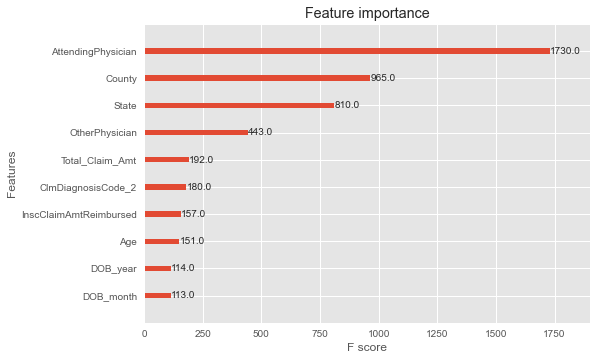

In [ ]:
plot_importance(xg_sm,importance_type='weight', max_num_features=10)

<AxesSubplot:title={'center':'Feature importance'}, xlabel='F score', ylabel='Features'>

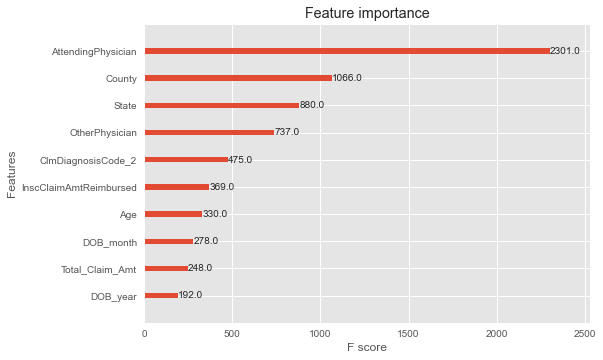

In [ ]:
plot_importance(xg_bsm,importance_type='weight', max_num_features=10)

### # Full set of evaluation metrics for both models:

- Confusion matrix:

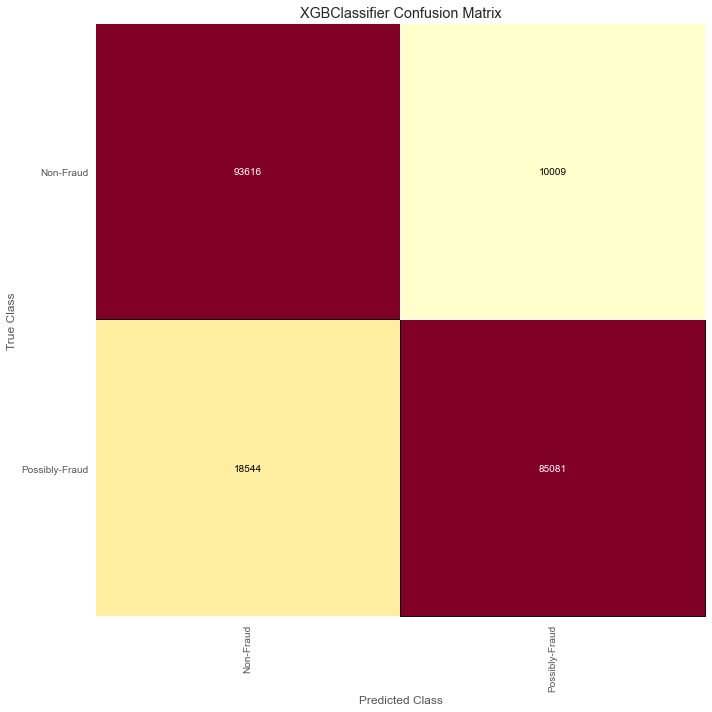

<AxesSubplot:title={'center':'XGBClassifier Confusion Matrix'}, xlabel='Predicted Class', ylabel='True Class'>

In [ ]:
# Visualizing the confusion matrix with Yellowbricks (thres=0.5)

plt.figure(figsize = (10,10))
visualizer = confusion_matrix(
    xg_sm,
    trainX_SM[selected_feat1], trainY_SM, testX_SM[selected_feat1], testY_SM,
    classes=['Non-Fraud', 'Possibly-Fraud'])

visualizer.show()

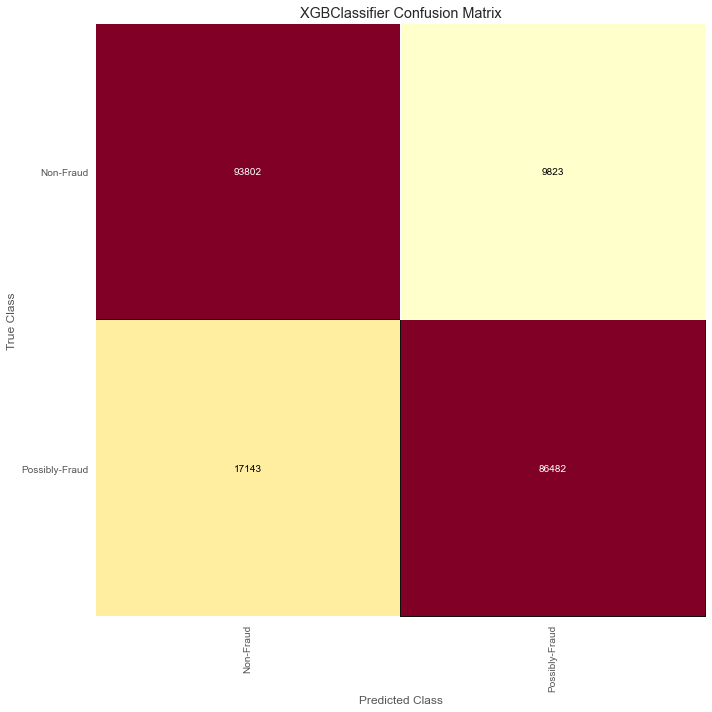

<AxesSubplot:title={'center':'XGBClassifier Confusion Matrix'}, xlabel='Predicted Class', ylabel='True Class'>

In [ ]:
# Visualizing the confusion matrix with Yellowbricks (thres=0.5)

plt.figure(figsize = (10,10))
visualizer = confusion_matrix(
    xg_bsm,
    trainX_BSM[selected_feat2], trainY_BSM, testX_BSM[selected_feat2], testY_BSM,
    classes=['Non-Fraud', 'Possibly-Fraud'])

visualizer.show()

- AUC/ROC curve

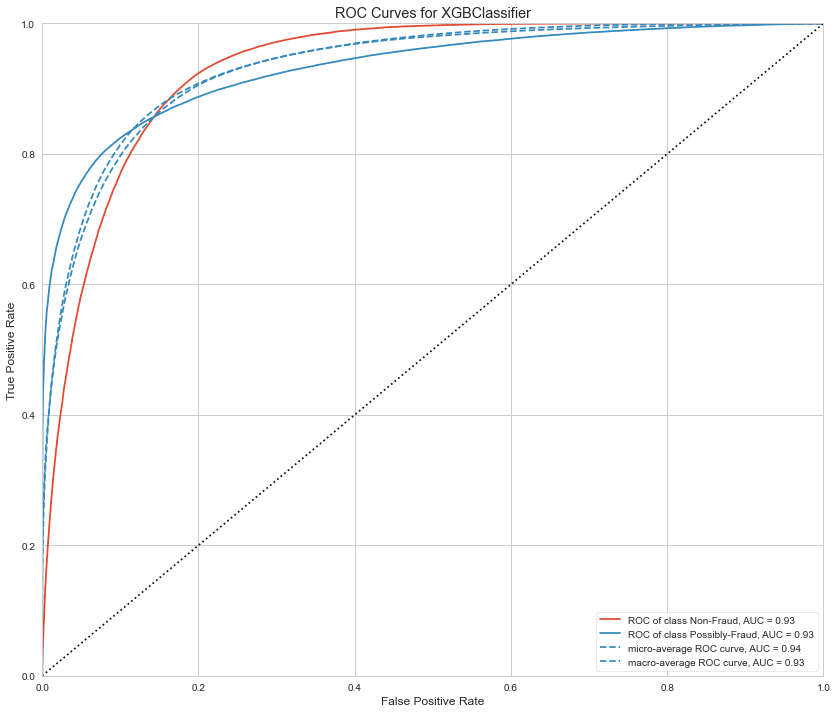

<AxesSubplot:title={'center':'ROC Curves for XGBClassifier'}, xlabel='False Positive Rate', ylabel='True Positive Rate'>

In [ ]:
# Visualizing the AUC/ROC curve with Yellowbricks

plt.figure(figsize = (14,12))
sns.set_style("whitegrid")

visualizer = ROCAUC(xg_sm, classes=['Non-Fraud', 'Possibly-Fraud'])

visualizer.fit(trainX_SM[selected_feat1], trainY_SM)        # Fit the training data to the visualizer
visualizer.score(testX_SM[selected_feat1], testY_SM)        # Evaluate the model on the test data

visualizer.show()

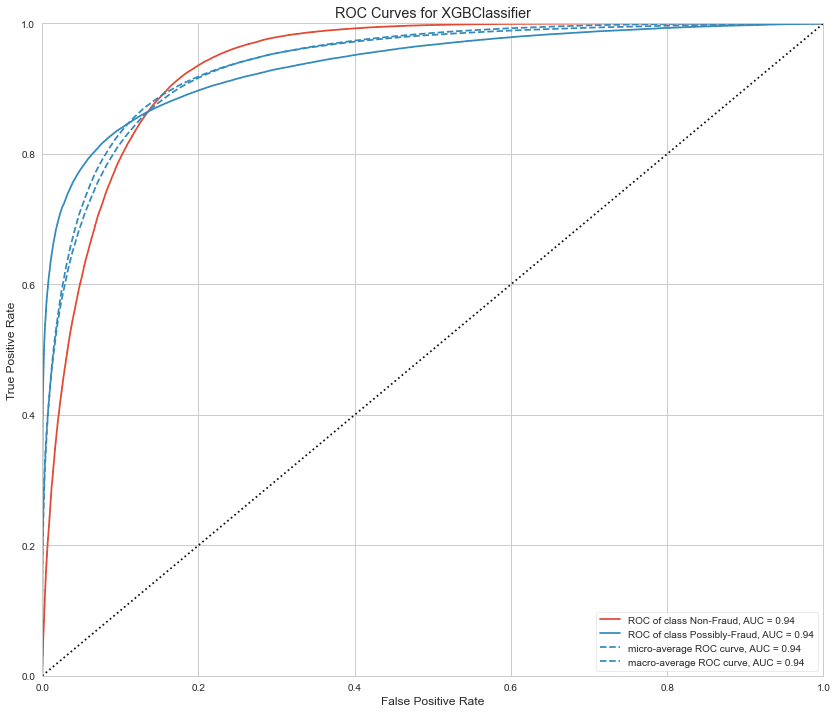

<AxesSubplot:title={'center':'ROC Curves for XGBClassifier'}, xlabel='False Positive Rate', ylabel='True Positive Rate'>

In [ ]:
# Visualizing the AUC/ROC curve with Yellowbricks

plt.figure(figsize = (14,12))
sns.set_style("whitegrid")

visualizer = ROCAUC(xg_bsm, classes=['Non-Fraud', 'Possibly-Fraud'])

visualizer.fit(trainX_BSM[selected_feat2], trainY_BSM)        # Fit the training data to the visualizer
visualizer.score(testX_BSM[selected_feat2], testY_BSM)        # Evaluate the model on the test data

visualizer.show()

- Classification report

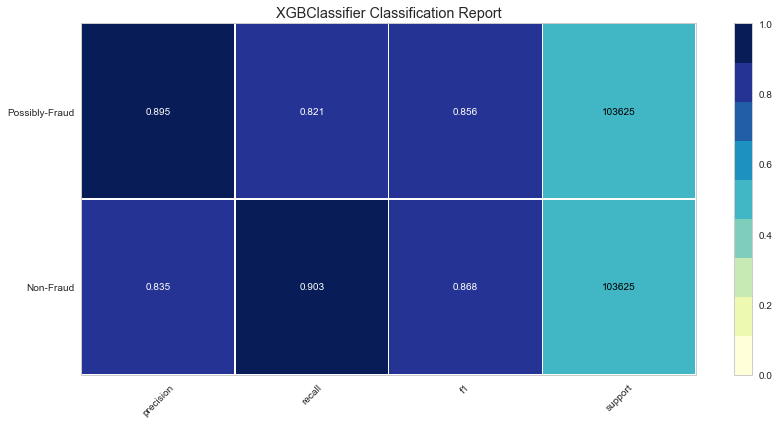

<AxesSubplot:title={'center':'XGBClassifier Classification Report'}>

In [ ]:
# Visualizing the classification report with Yellowbricks

plt.figure(figsize = (12,6))
sns.set_style("whitegrid")

visualizer = classification_report(
    xg_sm,
    trainX_SM[selected_feat1], trainY_SM, testX_SM[selected_feat1], testY_SM,
    classes=['Non-Fraud', 'Possibly-Fraud'],
    cmap='YlGnBu',
    support=True)

visualizer.show()

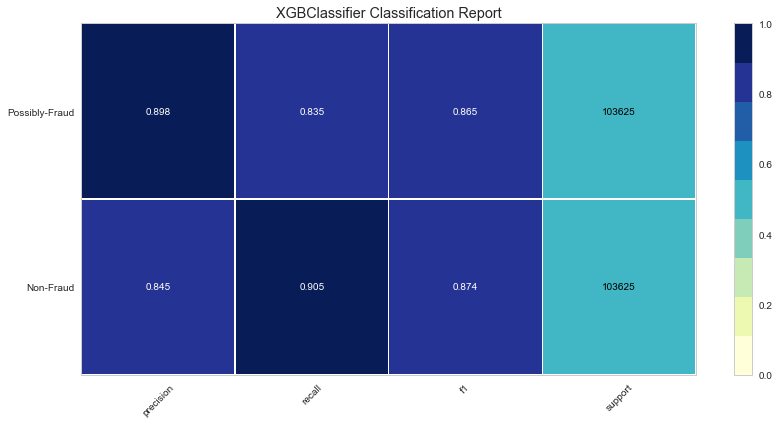

<AxesSubplot:title={'center':'XGBClassifier Classification Report'}>

In [ ]:
# Visualizing the classification report with Yellowbricks

plt.figure(figsize = (12,6))
sns.set_style("whitegrid")

visualizer = classification_report(
    xg_bsm,
    trainX_BSM[selected_feat2], trainY_BSM, testX_BSM[selected_feat2], testY_BSM,
    classes=['Non-Fraud', 'Possibly-Fraud'],
    cmap='YlGnBu',
    support=True)

visualizer.show()

- Precision-recall curve

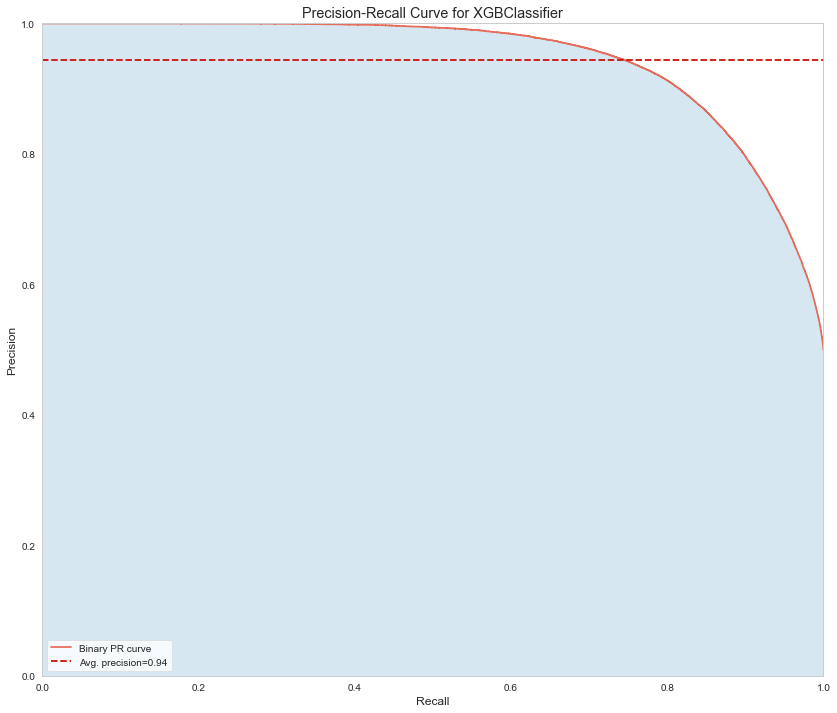

<AxesSubplot:title={'center':'Precision-Recall Curve for XGBClassifier'}, xlabel='Recall', ylabel='Precision'>

In [ ]:
# Visualizing precision-recall curve

from yellowbrick.classifier import precision_recall_curve

plt.figure(figsize = (14,12))
sns.set_style("whitegrid")
viz = precision_recall_curve(xg_sm, trainX_SM[selected_feat1], trainY_SM, testX_SM[selected_feat1], testY_SM)
viz.show()

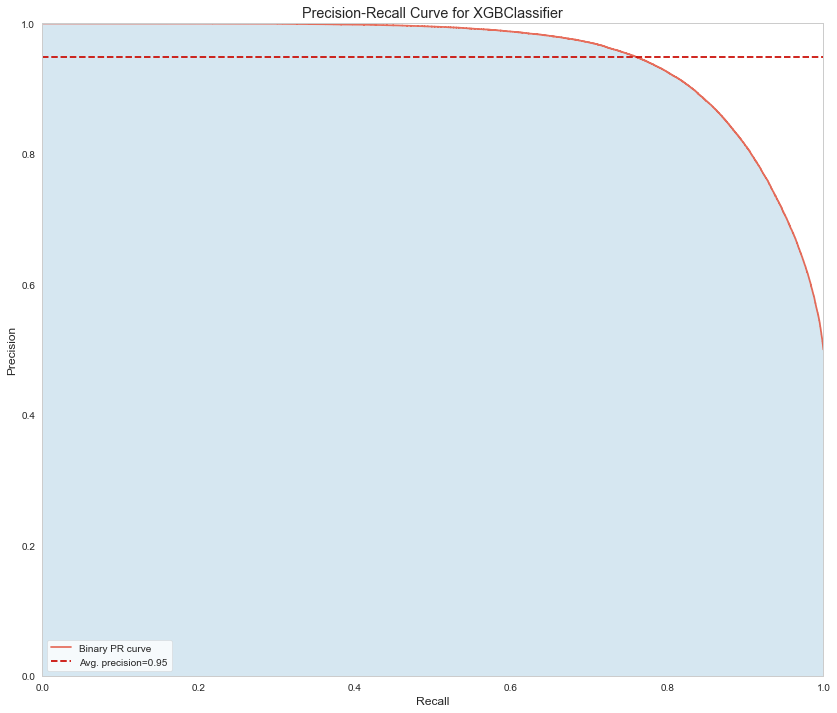

<AxesSubplot:title={'center':'Precision-Recall Curve for XGBClassifier'}, xlabel='Recall', ylabel='Precision'>

In [ ]:
# Visualizing precision-recall curve

plt.figure(figsize = (14,12))
sns.set_style("whitegrid")
viz = precision_recall_curve(xg_bsm, trainX_BSM[selected_feat2], trainY_BSM, testX_BSM[selected_feat2], testY_BSM)
viz.show()

- Prediction error

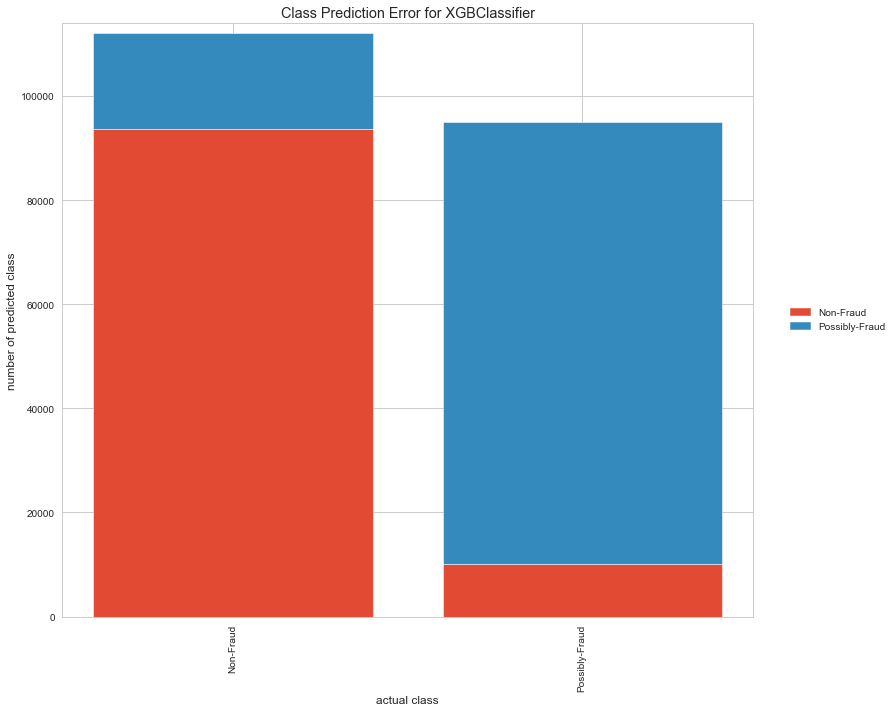

<AxesSubplot:title={'center':'Class Prediction Error for XGBClassifier'}, xlabel='actual class', ylabel='number of predicted class'>

In [ ]:
# Visualizing prediction error

from yellowbrick.classifier import class_prediction_error

plt.figure(figsize = (14,10))
sns.set_style("whitegrid")
viz = class_prediction_error(
    xg_sm,
    trainX_SM[selected_feat1], trainY_SM.values.ravel(),
    testX_SM[selected_feat1], testY_SM.values.ravel(),
    classes=['Non-Fraud', 'Possibly-Fraud'])

viz.show()

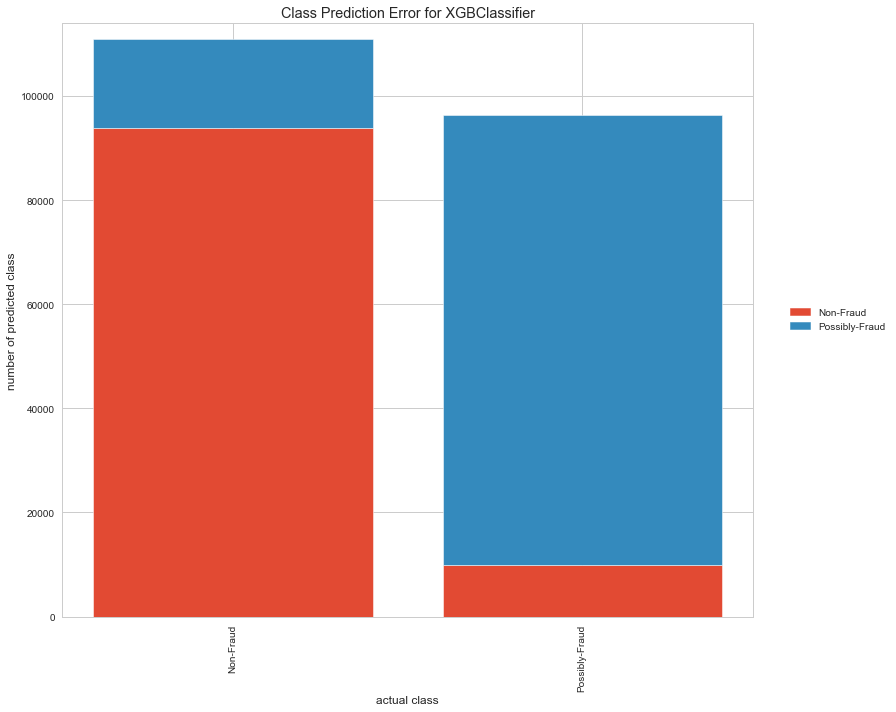

<AxesSubplot:title={'center':'Class Prediction Error for XGBClassifier'}, xlabel='actual class', ylabel='number of predicted class'>

In [ ]:
# Visualizing prediction error

plt.figure(figsize = (14,10))
sns.set_style("whitegrid")
viz = class_prediction_error(
    xg_bsm,
    trainX_BSM[selected_feat2], trainY_BSM.values.ravel(),
    testX_BSM[selected_feat2], testY_BSM.values.ravel(),
    classes=['Non-Fraud', 'Possibly-Fraud'])

viz.show()

### # Threshold selection for both:

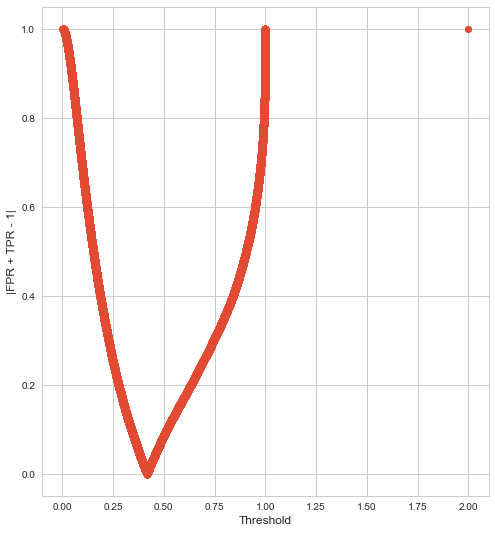

In [ ]:
# Visualizing the threshold

from sklearn.metrics import roc_curve

sns.set_style("whitegrid")
fpr1, tpr1, thresholds1 = roc_curve(trainY_SM,xg_sm.predict_proba(trainX_SM[selected_feat1])[:,1],drop_intermediate=False)

plt.figure(figsize = (8,9))
plt.scatter(thresholds1,np.abs(fpr1+tpr1-1),linewidths=0.3)
plt.xlabel("Threshold")
plt.ylabel("|FPR + TPR - 1|")
plt.show()

In [ ]:
thresholds1[np.argmin(np.abs(fpr1+tpr1-1))]

0.4169405

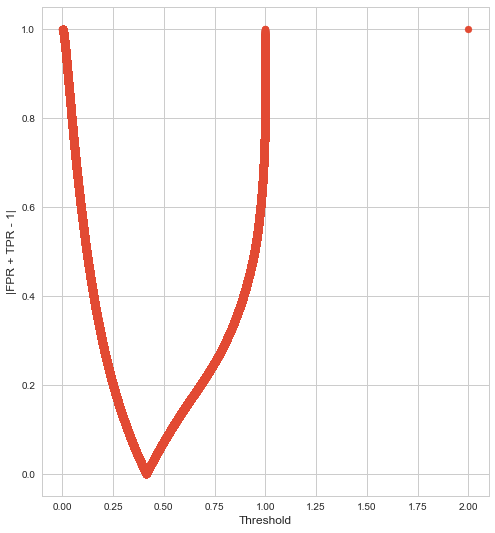

In [ ]:
# Visualizing the threshold

sns.set_style("whitegrid")
fpr2, tpr2, thresholds2 = roc_curve(trainY_BSM,xg_bsm.predict_proba(trainX_BSM[selected_feat2])[:,1],drop_intermediate=False)

plt.figure(figsize = (8,9))
plt.scatter(thresholds2,np.abs(fpr2+tpr2-1),linewidths=0.3)
plt.xlabel("Threshold")
plt.ylabel("|FPR + TPR - 1|")
plt.show()

In [ ]:
thresholds2[np.argmin(np.abs(fpr2+tpr2-1))]

0.41357762

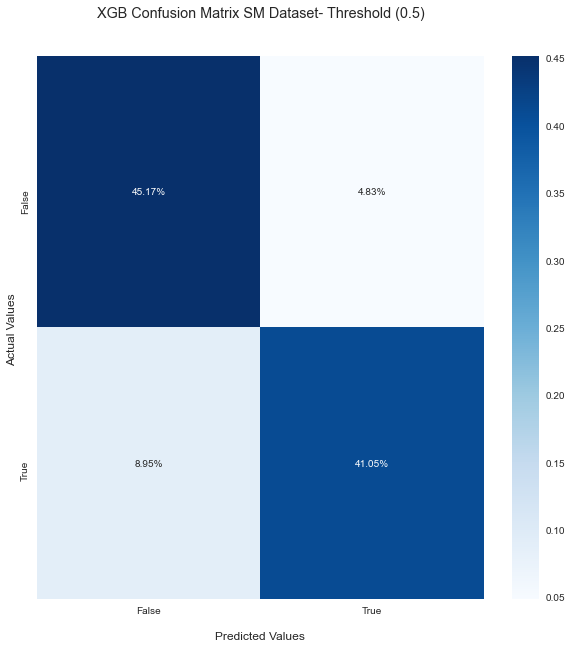

In [ ]:
# Looking at confusion matrix (thres=0.5)

cm1 = get_confusion_matrix(xg_sm, testX_SM[selected_feat1], testY_SM, thres=0.5)

#Plotting the confusion matrix

labels = ['Non-Fraud', 'Possibly-Fraud']

plt.figure(figsize = (10,10))

ax = sns.heatmap(cm1/np.sum(cm1), annot=True, fmt='.2%', cmap='Blues')

ax.set_title('XGB Confusion Matrix SM Dataset- Threshold (0.5)\n\n');
ax.set_xlabel('\nPredicted Values')
ax.set_ylabel('Actual Values ');

## Ticket labels - List must be in alphabetical order
ax.xaxis.set_ticklabels(['False','True'])
ax.yaxis.set_ticklabels(['False','True'])

## Display the visualization of the Confusion Matrix.
plt.show()

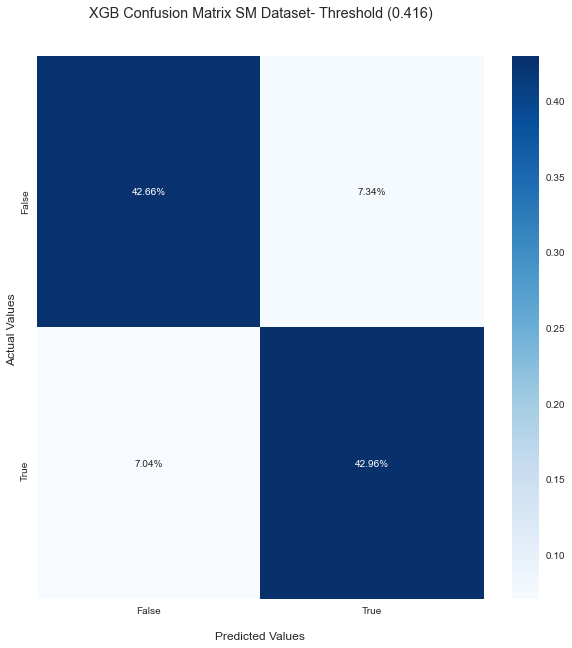

In [ ]:
# Looking at confusion matrix (thres=0.416)

cm1 = get_confusion_matrix(xg_sm, testX_SM[selected_feat1], testY_SM, thres=0.416)

#Plotting the confusion matrix

labels = ['Non-Fraud', 'Possibly-Fraud']

plt.figure(figsize = (10,10))

ax = sns.heatmap(cm1/np.sum(cm1), annot=True, fmt='.2%', cmap='Blues')

ax.set_title('XGB Confusion Matrix SM Dataset- Threshold (0.416)\n\n');
ax.set_xlabel('\nPredicted Values')
ax.set_ylabel('Actual Values ');

## Ticket labels - List must be in alphabetical order
ax.xaxis.set_ticklabels(['False','True'])
ax.yaxis.set_ticklabels(['False','True'])

## Display the visualization of the Confusion Matrix.
plt.show()

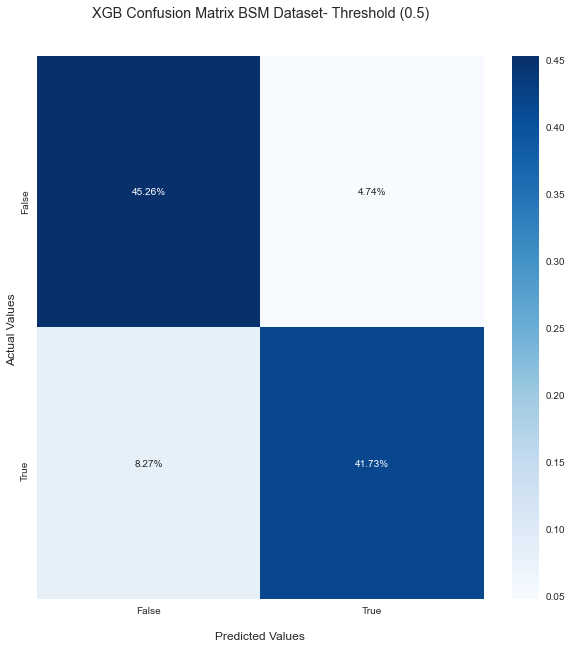

In [ ]:
# Looking at confusion matrix (thres=0.5)

cm2 = get_confusion_matrix(xg_bsm, testX_BSM[selected_feat2], testY_BSM, thres=0.5)

#Plotting the confusion matrix

labels = ['Non-Fraud', 'Possibly-Fraud']

plt.figure(figsize = (10,10))

ax = sns.heatmap(cm2/np.sum(cm2), annot=True, fmt='.2%', cmap='Blues')

ax.set_title('XGB Confusion Matrix BSM Dataset- Threshold (0.5)\n\n');
ax.set_xlabel('\nPredicted Values')
ax.set_ylabel('Actual Values ');

## Ticket labels - List must be in alphabetical order
ax.xaxis.set_ticklabels(['False','True'])
ax.yaxis.set_ticklabels(['False','True'])

## Display the visualization of the Confusion Matrix.
plt.show()

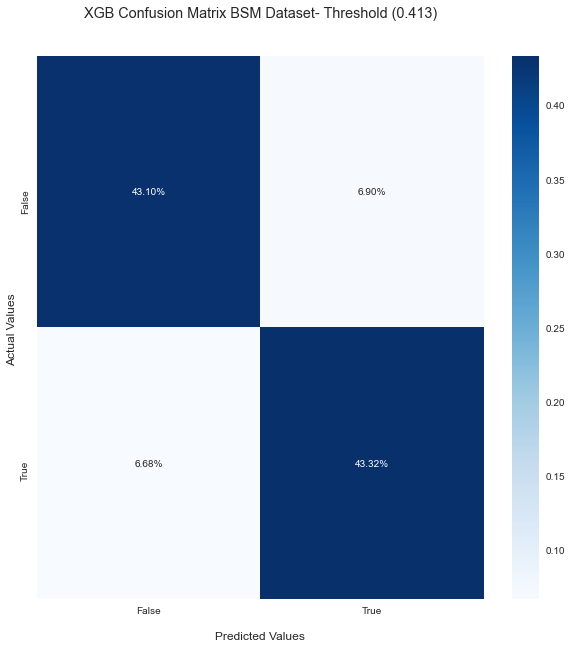

In [ ]:
# Looking at confusion matrix (thres=0.413)

cm2 = get_confusion_matrix(xg_bsm, testX_BSM[selected_feat2], testY_BSM, thres=0.413)

#Plotting the confusion matrix

labels = ['Non-Fraud', 'Possibly-Fraud']

plt.figure(figsize = (10,10))

ax = sns.heatmap(cm2/np.sum(cm2), annot=True, fmt='.2%', cmap='Blues')

ax.set_title('XGB Confusion Matrix BSM Dataset- Threshold (0.413)\n\n');
ax.set_xlabel('\nPredicted Values')
ax.set_ylabel('Actual Values ');

## Ticket labels - List must be in alphabetical order
ax.xaxis.set_ticklabels(['False','True'])
ax.yaxis.set_ticklabels(['False','True'])

## Display the visualization of the Confusion Matrix.
plt.show()